In [1]:
from collections import Counter
from pathlib import Path

import numpy as np

from intrarepresentational_alignment.analysis import (
    analyse_domain_pairs,
    group_domain_pairs,
)
from intrarepresentational_alignment.data import load_lcc, load_metanet
from intrarepresentational_alignment.embedding import Embedder
from intrarepresentational_alignment.embedding_models import EmbeddingModel
from intrarepresentational_alignment.graph import TopFraction
from intrarepresentational_alignment.similarity import CosineSimilarity, SparseKernel
from intrarepresentational_alignment.viz import (
    plot_cka_bar,
    plot_dense_vs_sparse,
    plot_ged_vs_cka,
    plot_method_detection_table,
    plot_model_comparison_heatmap,
    plot_model_comparison_significance,
    print_alignment_table,
    print_cka_table,
    print_dense_vs_sparse_table,
    print_method_detection_table,
    print_significance_summary,
    print_summary_table,
)

In [2]:
DATA_PATH      = Path("data/mr-en-20250924142102.rdf")
LCC_PATH       = Path("data/en_small.xml")
MIN_PAIRS      = 8
MAX_PAIRS      = 30
N_PERMS        = 500
EDGE_FRACTION  = 0.15
GED_THRESHOLD  = 0.4
SEED           = 42

## MetaNet


In [3]:
repo = load_metanet(DATA_PATH)
print(f"Loaded  {len(repo.metaphors):,} metaphors, {len(repo.frames):,} frames, "
      f"{len(repo.mappings):,} mappings, {len(repo.examples):,} examples")

http://metanet.english.ubc.ca/metaphor/MetaphorOntology.owl#Closest French frame does not look like a valid URI, trying to serialize this will break.


http://metanet.english.ubc.ca/metaphor/MetaphorOntology.owl#Closest Spanish frame does not look like a valid URI, trying to serialize this will break.


http://metanet.english.ubc.ca/metaphor/MetaphorOntology.owl#Metaphor_Experiential basis does not look like a valid URI, trying to serialize this will break.


http://metanet.english.ubc.ca/metaphor/MetaphorOntology.owl#Related metaphor_Description does not look like a valid URI, trying to serialize this will break.


Loaded  875 metaphors, 951 frames, 645 mappings, 5,616 examples


## LCC Metaphor Corpus


In [4]:
instances = load_lcc(LCC_PATH)
print(f"Loaded {len(instances):,} LCC instances")

all_domain_pairs = group_domain_pairs(instances)
print(f"With explicit source concept (excl. OTHER): {sum(len(v) for v in all_domain_pairs.values()):,} expression pairs")

print(f"Top 15 (source domain -> target domain) pairs:")
pair_counts = Counter({k: len(v) for k, v in all_domain_pairs.items()})
for (src, tgt), n in pair_counts.most_common(15):
    print(f"  {src:<30} -> {tgt:<25} (n={n})")

Loaded 16,265 LCC instances
With explicit source concept (excl. OTHER): 3,336 expression pairs
Top 15 (source domain -> target domain) pairs:
  DISEASE                        -> POVERTY                   (n=43)
  PROTECTION                     -> GUN_RIGHTS                (n=34)
  ABYSS                          -> POVERTY                   (n=22)
  PHYSICAL_LOCATION              -> POVERTY                   (n=22)
  PROTECTION                     -> GUNS                      (n=19)
  STRUGGLE                       -> POVERTY                   (n=18)
  PROTECTION                     -> DEMOCRACY                 (n=18)
  MOVEMENT                       -> CONTROL_OF_GUNS           (n=18)
  PHYSICAL_BURDEN                -> TAXATION                  (n=17)
  MOVEMENT                       -> GOVERNMENT                (n=17)
  MOVEMENT                       -> GUNS                      (n=16)
  ANIMAL                         -> GUNS                      (n=15)
  MOVEMENT                    

## Per-domain CKA experiments


In [5]:
MODEL_LABELS = {
    EmbeddingModel.WORD2VEC_GOOGLE_NEWS_300: "word2vec-300",
    EmbeddingModel.GLOVE_WIKI_GIGAWORD_50:   "glove-50",
    EmbeddingModel.GLOVE_WIKI_GIGAWORD_100:  "glove-100",
    EmbeddingModel.GLOVE_WIKI_GIGAWORD_300:  "glove-300",
    EmbeddingModel.FASTTEXT_WIKI_NEWS_300:   "fasttext-300",
    EmbeddingModel.CONCEPTNET_NUMBERBATCH_300: "numberbatch-300",
    EmbeddingModel.ALL_MINILM_L6_V2:          "minilm-l6-v2",
}

selected_pairs = {k: v for k, v in all_domain_pairs.items() if MIN_PAIRS <= len(v) <= MAX_PAIRS}
selected       = sorted(selected_pairs, key=lambda k: len(selected_pairs[k]), reverse=True)
print(f"Domains with {MIN_PAIRS}-{MAX_PAIRS} pairs: {len(selected)}")

all_model_results = {}
for model_id, label in MODEL_LABELS.items():
    print(f"Embedding with {label}...")
    embedder_m = Embedder(model_id)
    all_model_results[label] = analyse_domain_pairs(
        selected_pairs, embedder_m, n_permutations=N_PERMS,
        ged_threshold=GED_THRESHOLD,
        rng=np.random.default_rng(SEED),
    )

# glove-300 is the baseline used for all per-model plots below
embedder       = Embedder(EmbeddingModel.GLOVE_WIKI_GIGAWORD_300)
domain_results = all_model_results["glove-300"]
print_cka_table(domain_results, selected)

Domains with 8-30 pairs: 75
Embedding with word2vec-300...


Embedding with glove-50...


Embedding with glove-100...


Embedding with glove-300...


Embedding with fasttext-300...


...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

/vol/bitbucket/zl4624/intra-align/intrarepresentational_alignment/embedding.py:58: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  self.vector_size = self._model.get_sentence_embedding_dimension()


Source domain                Target domain             n     CKA       p
------------------------------------------------------------------------
ABYSS                        POVERTY                  22   0.498   0.000 *
PHYSICAL_LOCATION            POVERTY                  22  -0.014   0.886
PROTECTION                   GUNS                     19   0.435   0.006 *
STRUGGLE                     POVERTY                  18   0.331   0.490
PROTECTION                   DEMOCRACY                18   0.416   0.040 *
MOVEMENT                     CONTROL_OF_GUNS          18   0.276   0.178
PHYSICAL_BURDEN              TAXATION                 17   0.203   0.194
MOVEMENT                     GOVERNMENT               17   0.473   0.024 *
MOVEMENT                     GUNS                     16   0.216   0.986
ANIMAL                       GUNS                     13   0.507   0.502
MOVEMENT                     DEMOCRACY                14   0.439   0.118
BUILDING                     DEMOCRACY     

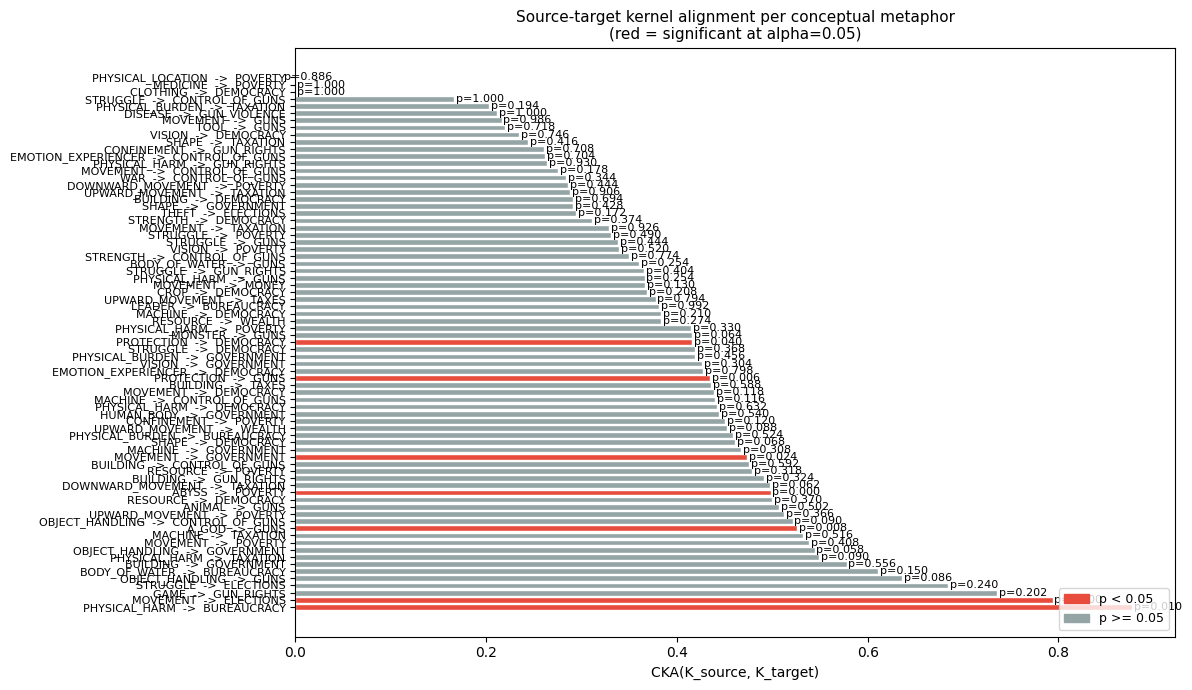

In [6]:
plot_cka_bar(domain_results)

### Graph distance alignment


In [7]:
print_alignment_table(domain_results, selected)

Source domain                Target domain             CKA     GED   p(CKA)   p(GED)
------------------------------------------------------------------------------------
ABYSS                        POVERTY                 0.498   0.639   0.000*   0.108 
PHYSICAL_LOCATION            POVERTY                -0.014   0.274   0.886    0.938 
PROTECTION                   GUNS                    0.435   0.553   0.006*   0.186 
STRUGGLE                     POVERTY                 0.331   0.747   0.490    0.974 
PROTECTION                   DEMOCRACY               0.416   0.639   0.040*   0.912 
MOVEMENT                     CONTROL_OF_GUNS         0.276   0.475   0.178    0.312 
PHYSICAL_BURDEN              TAXATION                0.203   0.340   0.194    0.252 
MOVEMENT                     GOVERNMENT              0.473   0.881   0.024*   0.356 
MOVEMENT                     GUNS                    0.216   0.650   0.986    0.932 
ANIMAL                       GUNS                    0.507   0.92

In [8]:
print_summary_table(domain_results, selected)

Source domain           Target domain              n     CKA   p(CKA)     GED   p(GED)
--------------------------------------------------------------------------------------
PHYSICAL_HARM           BUREAUCRACY                7   0.878   0.010*   0.451   0.004*
MOVEMENT                ELECTIONS                  8   0.794   0.000*   0.828   0.006*
OBJECT_HANDLING         GUNS                       8   0.636   0.086    0.662   0.022*
A_GOD                   GUNS                      10   0.526   0.008*   0.852   0.516 
ABYSS                   POVERTY                   22   0.498   0.000*   0.639   0.108 
MOVEMENT                GOVERNMENT                17   0.473   0.024*   0.881   0.356 
PROTECTION              GUNS                      19   0.435   0.006*   0.553   0.186 
PROTECTION              DEMOCRACY                 18   0.416   0.040*   0.639   0.912 
MOVEMENT                MONEY                     13   0.366   0.130    0.659   0.046*
-------------------------------------------

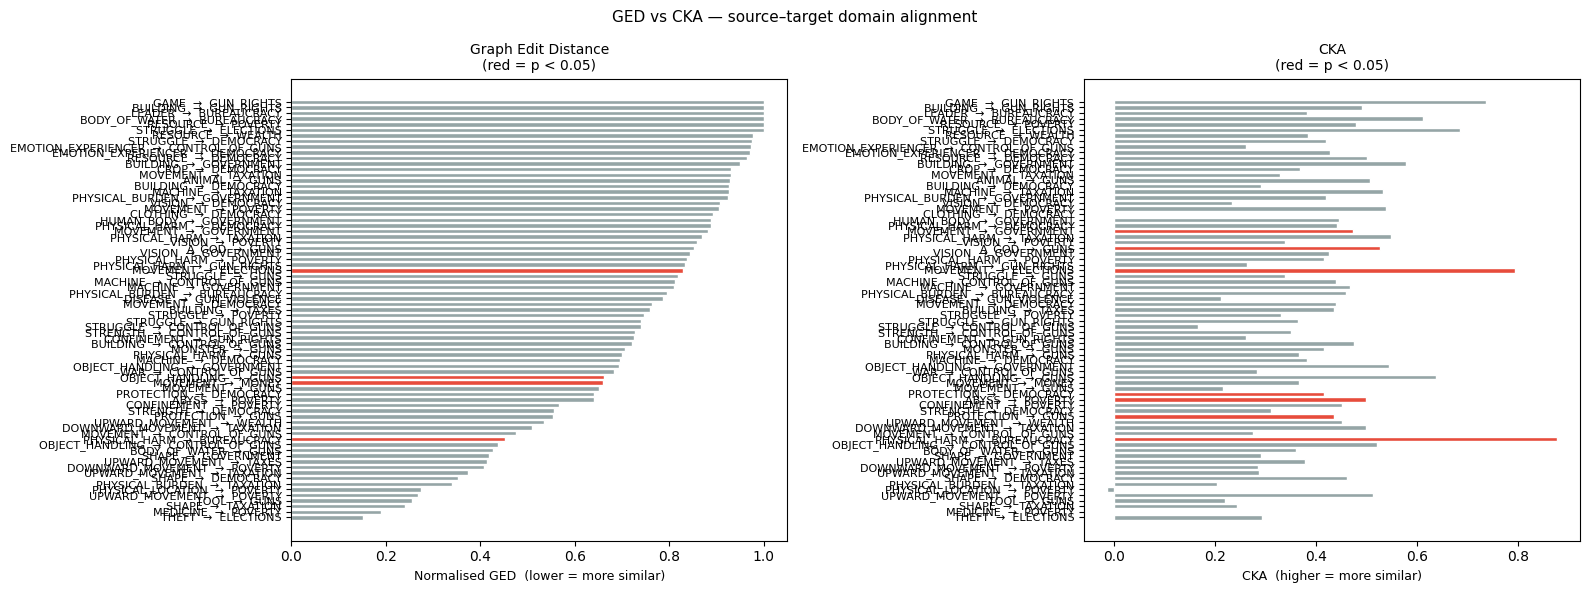

In [9]:
plot_ged_vs_cka(domain_results)

### Sparse kernel


In [10]:
sparse_metric  = SparseKernel(CosineSimilarity(), TopFraction(EDGE_FRACTION))
sparse_results = analyse_domain_pairs(
    selected_pairs, embedder, metric=sparse_metric, n_permutations=N_PERMS,
    ged_threshold=GED_THRESHOLD,
    rng=np.random.default_rng(SEED)
)
print_dense_vs_sparse_table(domain_results, sparse_results, selected)

Source domain                Target domain          CKA(dense)  CKA(sparse)  p(dense)  p(sparse)
------------------------------------------------------------------------------------------------
ABYSS                        POVERTY                     0.498        0.047     0.000 *      0.218  
PHYSICAL_LOCATION            POVERTY                    -0.014        0.144     0.886        0.038 *
PROTECTION                   GUNS                        0.435        0.124     0.006 *      0.092  
STRUGGLE                     POVERTY                     0.331        0.006     0.490        0.536  
PROTECTION                   DEMOCRACY                   0.416       -0.002     0.040 *      0.584  
MOVEMENT                     CONTROL_OF_GUNS             0.276        0.077     0.178        0.238  
PHYSICAL_BURDEN              TAXATION                    0.203        0.059     0.194        0.304  
MOVEMENT                     GOVERNMENT                  0.473        0.115     0.024 *      0.146 

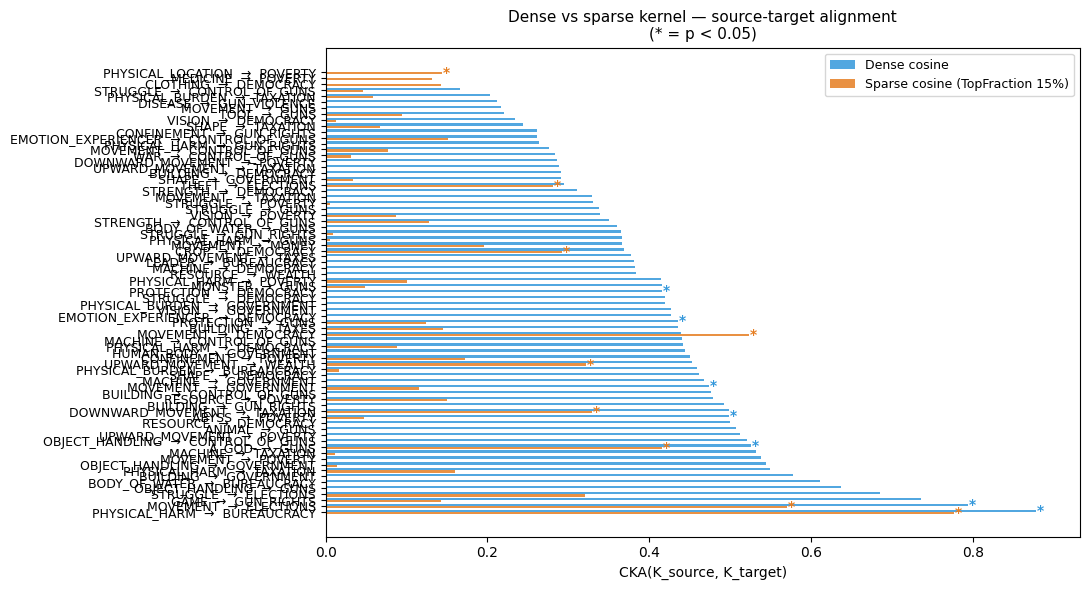

In [11]:
plot_dense_vs_sparse(domain_results, sparse_results, EDGE_FRACTION)

## Significance summary


In [12]:
print_significance_summary(domain_results, sparse_results, selected)

CKA identifies significant alignment between 7 metaphor-domain pairs.
Sparse GED identifies 7 significant pairs, 3 of which were previously identified by CKA.
Sparse GED contributes 4 new pairs beyond dense CKA (4 dense-CKA-only; 11 pairs significant by either metric in total).
  GED-only: DOWNWARD_MOVEMENT -> TAXATION
  GED-only: MOVEMENT -> DEMOCRACY
  GED-only: PHYSICAL_LOCATION -> POVERTY
  GED-only: UPWARD_MOVEMENT -> WEALTH
Metric         Dense      Sparse
--------------------------------
CKA                7 / 75           9 / 75
GED                4 / 75           7 / 75
--------------------------------
Any                9 / 75           9 / 75


## Word embedding model comparison

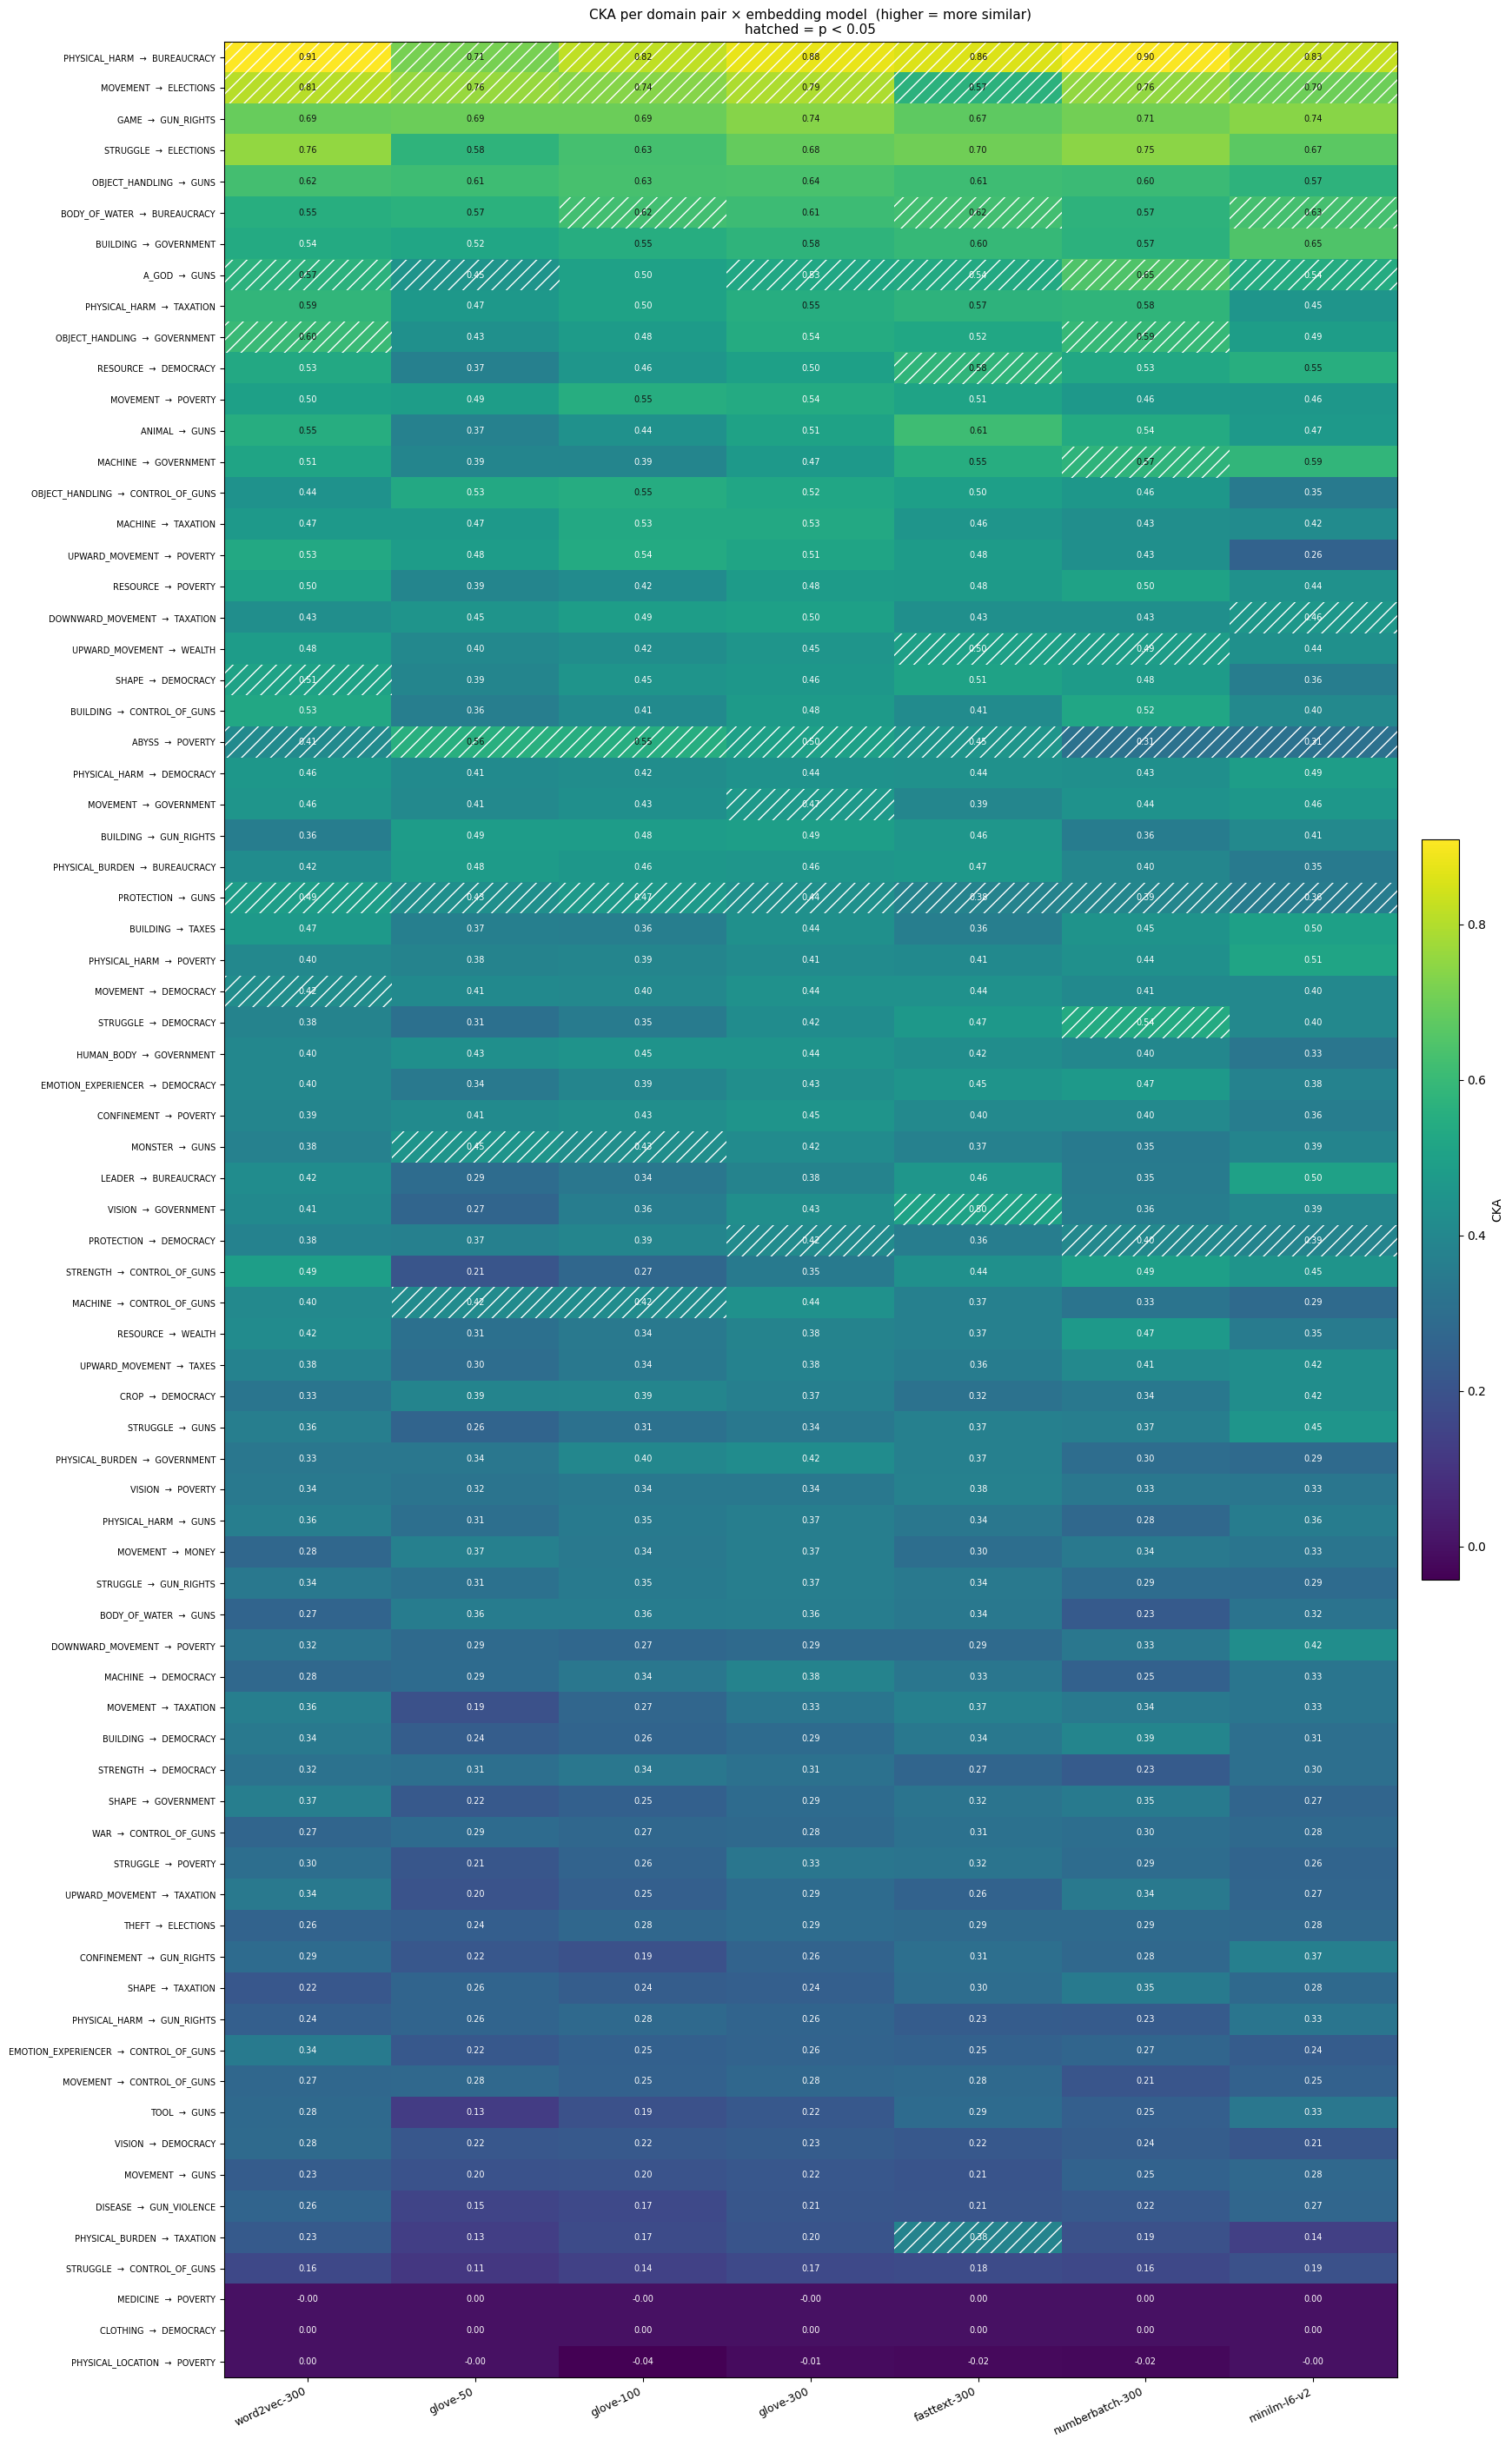

In [13]:
plot_model_comparison_heatmap(all_model_results, metric="cka")

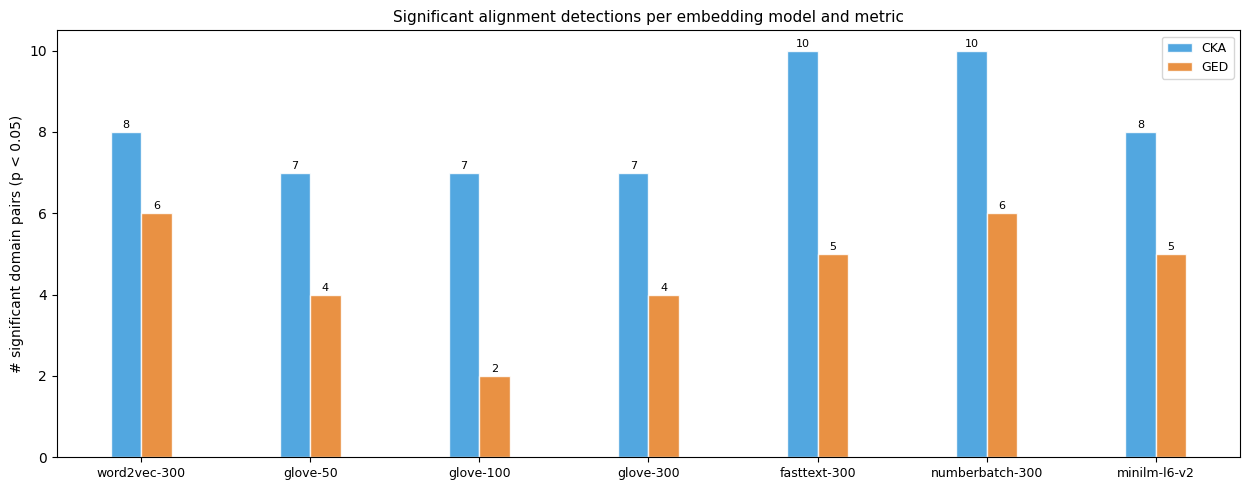

In [14]:
plot_model_comparison_significance(all_model_results)

### Method overlap table

Each cell shows **N (U)** where N = number of significant domain pairs at p < 0.05, and U = number of those pairs detected *only* by that metric (CKA but not GED, or vice versa) for that model.

In [15]:
print_method_detection_table(all_model_results, keys=selected)

Model                      CKA         GED
------------------------------------------
word2vec-300             8 (5)       6 (3)
glove-50                 7 (5)       4 (2)
glove-100                7 (5)       2 (0)
glove-300                7 (5)       4 (2)
fasttext-300            10 (8)       5 (3)
numberbatch-300         10 (7)       6 (3)
minilm-l6-v2             8 (4)       5 (1)
------------------------------------------
  N = significant at p < 0.05  |  (U) = unique to that metric  |  total pairs = 75


In [16]:
SIG = 0.05
cka_union = set()
ged_union = set()
either_union = set()

for model, res in all_model_results.items():
    for k in selected:
        if k in res:
            if res[k].cka.p_value < SIG:
                cka_union.add(k)
            if res[k].ged.p_value < SIG:
                ged_union.add(k)
            if res[k].cka.p_value < SIG or res[k].ged.p_value < SIG:
                either_union.add(k)

model_names = ", ".join(all_model_results)
print(f"Across all {len(all_model_results)} models ({model_names}):")
print(f"  CKA union  (found by CKA  in >=1 model): {len(cka_union)} / {len(selected)}")
print(f"  GED union  (found by GED  in >=1 model): {len(ged_union)} / {len(selected)}")
print(f"  Either     (CKA or GED   in >=1 model): {len(either_union)} / {len(selected)}")
print()
print("Pairs found by either metric across any model:")
for src, tgt in sorted(either_union):
    found_by = [m for m, r in all_model_results.items()
                if (src, tgt) in r and
                (r[(src, tgt)].cka.p_value < SIG or r[(src, tgt)].ged.p_value < SIG)]
    print(f"  {src:<30} -> {tgt:<25} ({len(found_by)}/{len(all_model_results)} models)")


Across all 7 models (word2vec-300, glove-50, glove-100, glove-300, fasttext-300, numberbatch-300, minilm-l6-v2):
  CKA union  (found by CKA  in >=1 model): 20 / 75
  GED union  (found by GED  in >=1 model): 13 / 75
  Either     (CKA or GED   in >=1 model): 25 / 75

Pairs found by either metric across any model:
  ABYSS                          -> POVERTY                   (7/7 models)
  A_GOD                          -> GUNS                      (6/7 models)
  BODY_OF_WATER                  -> BUREAUCRACY               (4/7 models)
  DOWNWARD_MOVEMENT              -> TAXATION                  (4/7 models)
  EMOTION_EXPERIENCER            -> DEMOCRACY                 (1/7 models)
  MACHINE                        -> CONTROL_OF_GUNS           (2/7 models)
  MACHINE                        -> GOVERNMENT                (1/7 models)
  MONSTER                        -> GUNS                      (2/7 models)
  MOVEMENT                       -> DEMOCRACY                 (1/7 models)
  MOVEMENT  

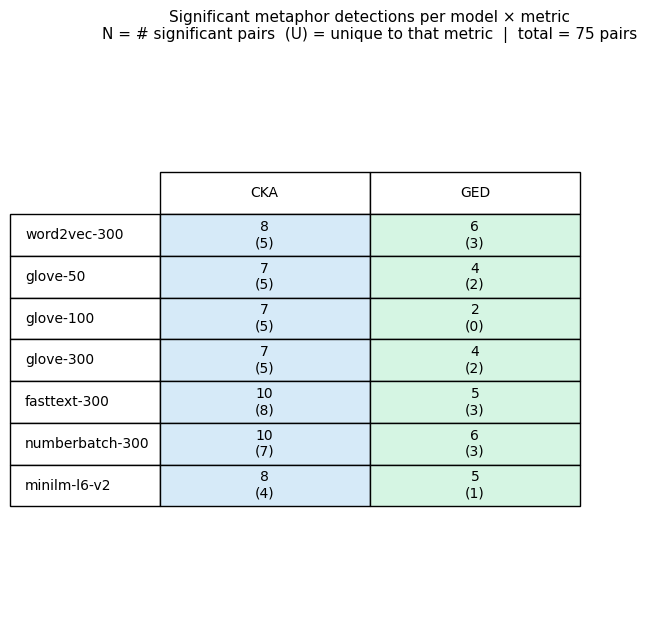

In [17]:
plot_method_detection_table(all_model_results, keys=selected)